# Modelos de Seguro Indexado para Café - Caldas

Implementación y comparación de tres modelos para el diseño de un seguro indexado agrícola.

**Período de análisis:** 2007-2024  
**Cobertura:** 25 municipios del departamento de Caldas  
**Variable objetivo:** Rendimiento del café (t/ha)

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import rankdata, gaussian_kde, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from copulas.bivariate import Frank, Gumbel, Clayton

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
import os
os.chdir('..')
print(os.getcwd())

C:\Users\nbellon\Documents\GitHub\proyecto_aplicado_en_analitica_de_datos


In [4]:
# Raíz del proyecto
PROJECT_ROOT = Path().resolve()
# Ruta a la carpeta de datos procesados
path = PROJECT_ROOT / "data" / "processed"
#df = pd.read_csv(path / 'Dataset_Consolidado.csv')
df = pd.read_csv(path / 'data_consolidada.csv')

## 2. Tratamiento y creación de variables

### 2.1 Ordenamiento y proxy de pérdida relativa

Se construye la variable objetivo del seguro: la pérdida relativa respecto al promedio histórico de cada municipio.

In [5]:
df = df.sort_values(['Municipio', 'Año']).reset_index(drop=True)

df['Rendimiento_prom_mun'] = df.groupby('Municipio')['Rendimiento (t/ha)'].transform('mean')
df['Perdida_relativa'] = (df['Rendimiento_prom_mun'] - df['Rendimiento (t/ha)']) / df['Rendimiento_prom_mun']

print(f'Pérdidas positivas (déficit): {(df["Perdida_relativa"] > 0).sum()}')
print(f'Pérdidas negativas (excedente): {(df["Perdida_relativa"] < 0).sum()}')

Pérdidas positivas (déficit): 244
Pérdidas negativas (excedente): 206


### 2.2 Índices climáticos

Construcción de TCI (Temperature Condition Index), VCI (Vegetation Condition Index) y VHI (Vegetation Health Index).

In [6]:
df['T2M_max_hist'] = df.groupby('Municipio')['T2M_prom_anual'].transform('max')
df['T2M_min_hist'] = df.groupby('Municipio')['T2M_prom_anual'].transform('min')
df['TCI'] = (df['T2M_max_hist'] - df['T2M_prom_anual']) / (df['T2M_max_hist'] - df['T2M_min_hist'])

df['NDVI_max_hist'] = df.groupby('Municipio')['NDVI_prom_anual'].transform('max')
df['NDVI_min_hist'] = df.groupby('Municipio')['NDVI_prom_anual'].transform('min')
df['VCI'] = (df['NDVI_prom_anual'] - df['NDVI_min_hist']) / (df['NDVI_max_hist'] - df['NDVI_min_hist'])

df['VHI'] = 0.5 * df['VCI'] + 0.5 * df['TCI']

### 2.3 Anomalías climáticas estandarizadas

In [7]:
for var, alias in [('PRECTOTCORR_total_anual', 'PREC'), ('T2M_prom_anual', 'T2M'), ('NDVI_prom_anual', 'NDVI')]:
    df[f'{alias}_prom_mun'] = df.groupby('Municipio')[var].transform('mean')
    df[f'{alias}_std_mun'] = df.groupby('Municipio')[var].transform('std')
    df[f'Anomalia_{alias}'] = (df[var] - df[f'{alias}_prom_mun']) / df[f'{alias}_std_mun']

### 2.4 Variables temporales (rezagos y promedios móviles)

Las variables temporales resultaron ser los predictores más fuertes en el análisis exploratorio.

In [8]:
df['Rendimiento_lag1'] = df.groupby('Municipio')['Rendimiento (t/ha)'].shift(1)
df['Perdida_lag1'] = df.groupby('Municipio')['Perdida_relativa'].shift(1)
df['Rendimiento_MA2_lag'] = df.groupby('Municipio')['Rendimiento (t/ha)'].transform(
    lambda x: x.shift(1).rolling(window=2, min_periods=1).mean()
)

df = df.dropna(subset=['Rendimiento_lag1']).reset_index(drop=True)
print(f'Observaciones después de crear lags: {df.shape[0]}')

Observaciones después de crear lags: 425


### 2.5 Validación de correlaciones con la variable objetivo

In [9]:
vars_check = ['TCI', 'VCI', 'VHI', 'Anomalia_PREC', 'Anomalia_T2M', 'Anomalia_NDVI',
              'Rendimiento_lag1', 'Perdida_lag1', 'Rendimiento_MA2_lag']

for var in vars_check:
    corr = df[[var, 'Perdida_relativa']].corr().iloc[0, 1]
    print(f'{var:25s} -> corr con pérdida: {corr:+.4f}')

TCI                       -> corr con pérdida: +0.0948
VCI                       -> corr con pérdida: -0.0404
VHI                       -> corr con pérdida: +0.0334
Anomalia_PREC             -> corr con pérdida: +0.0188
Anomalia_T2M              -> corr con pérdida: -0.0927
Anomalia_NDVI             -> corr con pérdida: -0.0420
Rendimiento_lag1          -> corr con pérdida: -0.3489
Perdida_lag1              -> corr con pérdida: +0.3851
Rendimiento_MA2_lag       -> corr con pérdida: -0.2380


## 3. Modelo 1: Índice Climático Compuesto + Cópula + Regresión Cuantílica

### 3.1 Construcción del índice climático

Se combina información climática y temporal mediante un promedio ponderado por la correlación absoluta de cada variable con la pérdida.

In [10]:
vars_indice = ['Anomalia_PREC', 'Anomalia_T2M', 'Anomalia_NDVI', 'TCI', 
               'estres_termico_hidrico', 'Perdida_lag1', 'Rendimiento_lag1']

scaler = StandardScaler()
X_idx = scaler.fit_transform(df[vars_indice])

# Ajustar dirección según signo de correlación con pérdida
for i, var in enumerate(vars_indice):
    corr = df[[var, 'Perdida_relativa']].corr().iloc[0, 1]
    if corr < 0:
        X_idx[:, i] = -X_idx[:, i]

pesos = np.array([abs(df[[v, 'Perdida_relativa']].corr().iloc[0, 1]) for v in vars_indice])
pesos = pesos / pesos.sum()

df['Indice_Completo'] = (X_idx * pesos).sum(axis=1)
print(f'Correlación índice-pérdida: {df[["Indice_Completo", "Perdida_relativa"]].corr().iloc[0, 1]:.4f}')

Correlación índice-pérdida: 0.3981


### 3.2 Ajuste de cópulas

Transformación a escala uniforme y selección de la mejor familia copularia por log-likelihood.

In [11]:
indice_u = rankdata(df['Indice_Completo']) / (len(df) + 1)
perdida_u = rankdata(df['Perdida_relativa']) / (len(df) + 1)
data_uniforme = np.column_stack([indice_u, perdida_u])

copulas = {'Frank': Frank(), 'Gumbel': Gumbel(), 'Clayton': Clayton()}
log_likelihoods = {}

for nombre, cop in copulas.items():
    cop.fit(data_uniforme)
    densidades = [np.log(cop.probability_density(data_uniforme[i:i+1])[0]) 
                  for i in range(len(data_uniforme)) 
                  if cop.probability_density(data_uniforme[i:i+1])[0] > 0]
    log_likelihoods[nombre] = sum(d for d in densidades if not np.isinf(d))
    print(f'{nombre}: LL = {log_likelihoods[nombre]:.2f}, theta = {cop.theta:.4f}')

mejor_copula = max(log_likelihoods, key=log_likelihoods.get)
print(f'\nMejor cópula: {mejor_copula}')

Frank: LL = 54.41, theta = 3.3280
Gumbel: LL = 40.68, theta = 1.5042
Clayton: LL = 48.93, theta = 1.0083

Mejor cópula: Frank


### 3.3 Regresión cuantílica condicional

In [12]:
X_qr = sm.add_constant(df[['Indice_Completo']])
y_qr = df['Perdida_relativa']

modelos_qr = {q: QuantReg(y_qr, X_qr).fit(q=q) for q in [0.05, 0.25, 0.50, 0.75, 0.95]}

for q, mod in modelos_qr.items():
    print(f'Q{int(q*100):2d}%: pérdida = {mod.params[0]:+.4f} + {mod.params[1]:+.4f} * índice')

Q 5%: pérdida = -0.3231 + +0.1492 * índice
Q25%: pérdida = -0.0896 + +0.1692 * índice
Q50%: pérdida = +0.0044 + +0.1567 * índice
Q75%: pérdida = +0.1011 + +0.1144 * índice
Q95%: pérdida = +0.3031 + -0.0006 * índice


### 3.4 Validación out-of-time del Modelo 1

In [13]:
train = df[df['Año'] <= 2020].copy()
test = df[df['Año'] >= 2021].copy()

X_train = sm.add_constant(train[['Indice_Completo']])
X_test = sm.add_constant(test[['Indice_Completo']])

modelos_train = {q: QuantReg(train['Perdida_relativa'], X_train).fit(q=q) for q in [0.05, 0.50, 0.95]}

test['Perdida_pred_Q50'] = modelos_train[0.50].predict(X_test)
test['Perdida_pred_Q5'] = modelos_train[0.05].predict(X_test)
test['Perdida_pred_Q95'] = modelos_train[0.95].predict(X_test)

test['Rendimiento_pred'] = test['Rendimiento_prom_mun'] * (1 - test['Perdida_pred_Q50'])
test['Rend_Q5'] = test['Rendimiento_prom_mun'] * (1 - test['Perdida_pred_Q95'])
test['Rend_Q95'] = test['Rendimiento_prom_mun'] * (1 - test['Perdida_pred_Q5'])

y_real = test['Rendimiento (t/ha)']
y_pred = test['Rendimiento_pred']

eventos_ext_m1 = test[test['Perdida_relativa'] > 0.20]
captura_m1 = (eventos_ext_m1['Perdida_pred_Q50'] > 0.05).sum() / len(eventos_ext_m1) if len(eventos_ext_m1) > 0 else 0

metricas_m1 = {
    'MAPE': mean_absolute_percentage_error(y_real, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
    'R2': r2_score(y_real, y_pred),
    'Pearson': pearsonr(y_real, y_pred)[0],
    'Cobertura': ((y_real >= test['Rend_Q5']) & (y_real <= test['Rend_Q95'])).mean(),
    'Captura_extremos': captura_m1
}

print('Resultados Modelo 1:')
for k, v in metricas_m1.items():
    print(f'  {k}: {v:.4f}')

Resultados Modelo 1:
  MAPE: 0.1531
  RMSE: 0.2247
  R2: 0.5314
  Pearson: 0.7333
  Cobertura: 0.9100
  Captura_extremos: 0.6667


## 4. Modelo 2: GMM + KDE + Payoff Condor-like

### 4.1 Segmentación de municipios por GMM

Inicialmente se probó con 3 clusters pero Manizales quedaba aislado. Se ajustó a 4 clusters para una segmentación balanceada.

In [14]:
df_municipios = df.groupby('Municipio').agg({
    'Rendimiento (t/ha)': ['mean', 'std'],
    'NDVI_prom_anual': 'mean',
    'Perdida_relativa': 'std'
}).reset_index()
df_municipios.columns = ['Municipio', 'Rend_mean', 'Rend_std', 'NDVI_mean', 'Volatilidad']

X_cluster = StandardScaler().fit_transform(df_municipios[['Rend_mean', 'Volatilidad', 'NDVI_mean']])

gmm = GaussianMixture(n_components=4, random_state=42, n_init=10)
df_municipios['Cluster'] = gmm.fit_predict(X_cluster)

mun_to_cluster = dict(zip(df_municipios['Municipio'], df_municipios['Cluster']))
df['Cluster'] = df['Municipio'].map(mun_to_cluster)

print('Distribución de municipios por cluster:')
print(df_municipios.groupby('Cluster')['Municipio'].count())

Distribución de municipios por cluster:
Cluster
0    12
1     7
2     3
3     3
Name: Municipio, dtype: int64


### 4.2 Estimación de distribuciones por KDE

In [15]:
kde_por_cluster = {}
for c in sorted(df['Cluster'].unique()):
    perdidas_c = df[df['Cluster'] == c]['Perdida_relativa'].values
    kde_por_cluster[c] = gaussian_kde(perdidas_c, bw_method='scott')

### 4.3 Definición de umbrales Condor-like

Cuatro umbrales por cluster: UL (Q5%), UT (Q25%), LT (Q75%), LL (Q95%).

In [16]:
umbrales_cluster = {}
for c in sorted(df['Cluster'].unique()):
    perdidas_c = df[df['Cluster'] == c]['Perdida_relativa'].values
    umbrales_cluster[c] = {
        'UL': np.quantile(perdidas_c, 0.05),
        'UT': np.quantile(perdidas_c, 0.25),
        'LT': np.quantile(perdidas_c, 0.75),
        'LL': np.quantile(perdidas_c, 0.95),
        'rendimiento_prom': df[df['Cluster'] == c]['Rendimiento_prom_mun'].mean()
    }
    print(f'Cluster {c}: UL={umbrales_cluster[c]["UL"]:+.3f}, LT={umbrales_cluster[c]["LT"]:+.3f}, LL={umbrales_cluster[c]["LL"]:+.3f}')

Cluster 0: UL=-0.444, LT=+0.143, LL=+0.342
Cluster 1: UL=-0.458, LT=+0.163, LL=+0.303
Cluster 2: UL=-0.229, LT=+0.127, LL=+0.216
Cluster 3: UL=-0.245, LT=+0.072, LL=+0.204


### 4.4 Función de payoff y cálculo de indemnizaciones

In [17]:
def payoff_condor(perdida, umbrales, pago_max=1.0):
    """Payoff Condor-like: sin pago debajo de LT, proporcional entre LT-LL, máximo sobre LL."""
    LT, LL = umbrales['LT'], umbrales['LL']
    if perdida < LT:
        return 0
    elif perdida < LL:
        return (perdida - LT) / (LL - LT) * pago_max
    return pago_max

df['Payoff'] = df.apply(
    lambda row: payoff_condor(row['Perdida_relativa'], umbrales_cluster[row['Cluster']]),
    axis=1
)

### 4.5 Validación out-of-time del Modelo 2

La cobertura se calcula como porcentaje de observaciones donde el seguro funciona correctamente: paga cuando hay pérdida significativa (>10%) o no paga cuando no hay pérdida.

In [18]:
train_m2 = df[df['Año'] <= 2020].copy()
test_m2 = df[df['Año'] >= 2021].copy()

# Recalcular umbrales solo con train
umbrales_train = {}
for c in sorted(train_m2['Cluster'].unique()):
    perdidas_c = train_m2[train_m2['Cluster'] == c]['Perdida_relativa'].values
    umbrales_train[c] = {
        'UL': np.quantile(perdidas_c, 0.05),
        'UT': np.quantile(perdidas_c, 0.25),
        'LT': np.quantile(perdidas_c, 0.75),
        'LL': np.quantile(perdidas_c, 0.95),
        'rendimiento_prom': train_m2[train_m2['Cluster'] == c]['Rendimiento_prom_mun'].mean()
    }

test_m2['Payoff_pred'] = test_m2.apply(
    lambda row: payoff_condor(row['Perdida_relativa'], umbrales_train[row['Cluster']]), axis=1
)

test_m2['Perdida_pred'] = test_m2.apply(
    lambda row: row['Payoff_pred'] * (umbrales_train[row['Cluster']]['LL'] - umbrales_train[row['Cluster']]['LT']) + umbrales_train[row['Cluster']]['LT'] 
    if row['Payoff_pred'] > 0 else 0, axis=1
)
test_m2['Rendimiento_pred'] = test_m2['Rendimiento_prom_mun'] * (1 - test_m2['Perdida_pred'])

y_real_m2 = test_m2['Rendimiento (t/ha)']
y_pred_m2 = test_m2['Rendimiento_pred']

# Cobertura: porcentaje de aciertos del seguro (paga si hay pérdida, no paga si no hay)
test_m2['perdida_significativa'] = test_m2['Perdida_relativa'] > 0.10
test_m2['seguro_pago'] = test_m2['Payoff_pred'] > 0
cobertura_m2 = ((test_m2['perdida_significativa'] & test_m2['seguro_pago']) | 
                (~test_m2['perdida_significativa'] & ~test_m2['seguro_pago'])).mean()

eventos_ext = test_m2[test_m2['Perdida_relativa'] > 0.20]
captura_m2 = (eventos_ext['Payoff_pred'] > 0).sum() / len(eventos_ext) if len(eventos_ext) > 0 else 0

metricas_m2 = {
    'MAPE': mean_absolute_percentage_error(y_real_m2, y_pred_m2),
    'RMSE': np.sqrt(mean_squared_error(y_real_m2, y_pred_m2)),
    'R2': r2_score(y_real_m2, y_pred_m2),
    'Pearson': pearsonr(y_real_m2, y_pred_m2)[0],
    'Cobertura': cobertura_m2,
    'Captura_extremos': captura_m2
}

print('Resultados Modelo 2:')
for k, v in metricas_m2.items():
    print(f'  {k}: {v:.4f}')

Resultados Modelo 2:
  MAPE: 0.0914
  RMSE: 0.2349
  R2: 0.4881
  Pearson: 0.7762
  Cobertura: 0.9400
  Captura_extremos: 1.0000


## 5. Modelo 3: Random Forest + Quantile Forests

### 5.1 Preparación de features y split temporal

In [19]:
features = [
    'PRECTOTCORR_total_anual', 'T2M_prom_anual', 'NDVI_prom_anual',
    'RH2M_prom_anual', 'GWETROOT_prom_anual', 'WS2M_prom_anual',
    'PRECTOTCORR_std_mes', 'T2M_std_mes', 'NDVI_std_anual',
    'TCI', 'VCI', 'VHI',
    'Anomalia_PREC', 'Anomalia_T2M', 'Anomalia_NDVI',
    'estres_termico_hidrico', 'exceso_humedad_proxy',
    'Rendimiento_lag1', 'Perdida_lag1', 'Rendimiento_MA2_lag',
    'Cluster', 'Área sembrada (ha)'
]

train_m3 = df[df['Año'] <= 2020].copy()
test_m3 = df[df['Año'] >= 2021].copy()

X_train = train_m3[features]
y_train = train_m3['Rendimiento (t/ha)']
X_test = test_m3[features]
y_test = test_m3['Rendimiento (t/ha)']

### 5.2 Optimización de hiperparámetros

In [20]:
param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print(f'Mejores parámetros: {rf_grid.best_params_}')

Mejores parámetros: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


### 5.3 Predicciones cuantílicas con el ensemble

In [21]:
def quantile_predictions(rf_model, X, quantiles=[0.05, 0.50, 0.95]):
    """Extrae cuantiles de las predicciones individuales de cada árbol del ensemble."""
    preds_arboles = np.array([tree.predict(X) for tree in rf_model.estimators_])
    return {q: np.quantile(preds_arboles, q, axis=0) for q in quantiles}

preds_q = quantile_predictions(best_rf, X_test, [0.05, 0.50, 0.95])

test_m3['Pred_Q5'] = preds_q[0.05]
test_m3['Pred_Q50'] = preds_q[0.50]
test_m3['Pred_Q95'] = preds_q[0.95]

### 5.4 Importancia de variables y métricas finales

In [22]:
importancias = pd.DataFrame({
    'variable': features,
    'importancia': best_rf.feature_importances_
}).sort_values('importancia', ascending=False)

print('Top 10 variables más importantes:')
print(importancias.head(10).to_string(index=False))

Top 10 variables más importantes:
           variable  importancia
   Rendimiento_lag1     0.264147
Rendimiento_MA2_lag     0.146476
PRECTOTCORR_std_mes     0.097822
       Perdida_lag1     0.053796
    NDVI_prom_anual     0.049548
        T2M_std_mes     0.043091
 Área sembrada (ha)     0.039909
                VHI     0.034131
     NDVI_std_anual     0.034031
    WS2M_prom_anual     0.030145


In [23]:
y_pred_m3 = best_rf.predict(X_test)

test_m3['Rendimiento_prom_mun_test'] = test_m3.groupby('Municipio')['Rendimiento (t/ha)'].transform('mean')
test_m3['Perdida_real'] = (test_m3['Rendimiento_prom_mun_test'] - test_m3['Rendimiento (t/ha)']) / test_m3['Rendimiento_prom_mun_test']
eventos_ext_m3 = test_m3[test_m3['Perdida_real'] > 0.20]
captura_m3 = (eventos_ext_m3['Pred_Q50'] < eventos_ext_m3['Rendimiento_prom_mun_test'] * 0.85).sum() / len(eventos_ext_m3) if len(eventos_ext_m3) > 0 else 0

metricas_m3 = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_m3),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_m3)),
    'R2': r2_score(y_test, y_pred_m3),
    'Pearson': pearsonr(y_test, y_pred_m3)[0],
    'Cobertura': ((y_test >= test_m3['Pred_Q5']) & (y_test <= test_m3['Pred_Q95'])).mean(),
    'Captura_extremos': captura_m3
}

print('Resultados Modelo 3:')
for k, v in metricas_m3.items():
    print(f'  {k}: {v:.4f}')

Resultados Modelo 3:
  MAPE: 0.1743
  RMSE: 0.2708
  R2: 0.3195
  Pearson: 0.6686
  Cobertura: 0.8200
  Captura_extremos: 0.3750


## 6. Comparación final de los tres modelos

In [24]:
comparacion = pd.DataFrame([
    {'Modelo': 'M1: Cópula + QR', **{k: round(v, 4) for k, v in metricas_m1.items()}},
    {'Modelo': 'M2: GMM + KDE + Condor', **{k: round(v, 4) for k, v in metricas_m2.items()}},
    {'Modelo': 'M3: Random Forest', **{k: round(v, 4) for k, v in metricas_m3.items()}}
])

print(comparacion.to_string(index=False))

                Modelo   MAPE   RMSE     R2  Pearson  Cobertura  Captura_extremos
       M1: Cópula + QR 0.1531 0.2247 0.5314   0.7333       0.91            0.6667
M2: GMM + KDE + Condor 0.0914 0.2349 0.4881   0.7762       0.94            1.0000
     M3: Random Forest 0.1743 0.2708 0.3195   0.6686       0.82            0.3750


## 7. Cálculo de prima técnica por cluster y municipio

Con base en el Modelo 2 (mejor desempeño), se calculan las primas técnicas. La cobertura máxima se ajusta al producto del rendimiento promedio, la pérdida máxima histórica del cluster (Q95%) y el precio del café, para evitar primas excesivas en clusters de baja volatilidad.

### 7.1 Parámetros y cálculo

In [25]:
PRECIO_CAFE = 5460  # USD/ton (FNCC)
RECARGO = 0.15  # Recargo administrativo del 15%

primas = []
for mun in sorted(df['Municipio'].unique()):
    cluster = mun_to_cluster[mun]
    df_mun = df[df['Municipio'] == mun]
    
    perdida_max_q95 = df[df['Cluster'] == cluster]['Perdida_relativa'].quantile(0.95)
    rend_prom = df_mun['Rendimiento (t/ha)'].mean()
    
    cobertura = rend_prom * perdida_max_q95 * PRECIO_CAFE
    
    payoffs = [payoff_condor(p, umbrales_cluster[cluster]) for p in df_mun['Perdida_relativa']]
    E_payoff = np.mean(payoffs)
    
    prima_pura = E_payoff * cobertura
    prima_comercial = prima_pura * (1 + RECARGO)
    
    primas.append({
        'Municipio': mun,
        'Cluster': cluster,
        'Rendimiento_prom': round(rend_prom, 3),
        'Cobertura_USD_ha': round(cobertura, 2),
        'E_Payoff': round(E_payoff, 4),
        'Prima_pura_USD': round(prima_pura, 2),
        'Prima_comercial_USD': round(prima_comercial, 2),
        'Prima_pct_cobertura': round(prima_comercial/cobertura*100, 2)
    })

primas_df = pd.DataFrame(primas).sort_values('Prima_comercial_USD', ascending=False).reset_index(drop=True)

### 7.2 Resumen por cluster

In [26]:
resumen_cluster = primas_df.groupby('Cluster').agg({
    'Municipio': 'count',
    'Rendimiento_prom': 'mean',
    'Cobertura_USD_ha': 'mean',
    'E_Payoff': 'mean',
    'Prima_comercial_USD': ['mean', 'min', 'max'],
    'Prima_pct_cobertura': 'mean'
}).round(2)

resumen_cluster.columns = ['N_Municipios', 'Rend_promedio', 'Cobertura_prom', 
                            'E_Payoff_prom', 'Prima_promedio', 'Prima_min', 'Prima_max', 'Prima_pct_prom']

print('Resumen de primas por cluster:')
print(resumen_cluster.to_string())

Resumen de primas por cluster:
         N_Municipios  Rend_promedio  Cobertura_prom  E_Payoff_prom  Prima_promedio  Prima_min  Prima_max  Prima_pct_prom
Cluster                                                                                                                  
0                  12           1.10         2052.54           0.12          281.98     134.44     494.99           13.88
1                   7           1.31         2175.66           0.15          374.66     167.93     628.54           16.93
2                   3           1.09         1287.38           0.14          203.39     179.29     234.52           15.78
3                   3           1.05         1164.97           0.15          205.02     172.93     252.66           17.57


### 7.3 Detalle por municipio

In [27]:
print('Primas técnicas por municipio (ordenadas de mayor a menor):')
print(primas_df.to_string(index=False))

print(f'\nResumen general:')
print(f'  Prima promedio:  ${primas_df["Prima_comercial_USD"].mean():.2f} USD/ha')
print(f'  Prima mínima:    ${primas_df["Prima_comercial_USD"].min():.2f} USD/ha ({primas_df.iloc[-1]["Municipio"]})')
print(f'  Prima máxima:    ${primas_df["Prima_comercial_USD"].max():.2f} USD/ha ({primas_df.iloc[0]["Municipio"]})')

Primas técnicas por municipio (ordenadas de mayor a menor):
  Municipio  Cluster  Rendimiento_prom  Cobertura_USD_ha  E_Payoff  Prima_pura_USD  Prima_comercial_USD  Prima_pct_cobertura
  Palestina        1             1.352           2238.70    0.2441          546.55               628.54                28.08
  Manizales        1             1.465           2425.75    0.1904          461.87               531.16                21.90
   Victoria        0             1.135           2117.83    0.2032          430.43               494.99                23.37
 Villamaria        0             1.043           1945.55    0.2106          409.66               471.11                24.21
   Riosucio        0             1.119           2087.10    0.1831          382.07               439.38                21.05
    Viterbo        1             1.299           2151.03    0.1736          373.46               429.48                19.97
     Pacora        0             1.005           1875.32    0.190

### 7.4 Visualización de primas

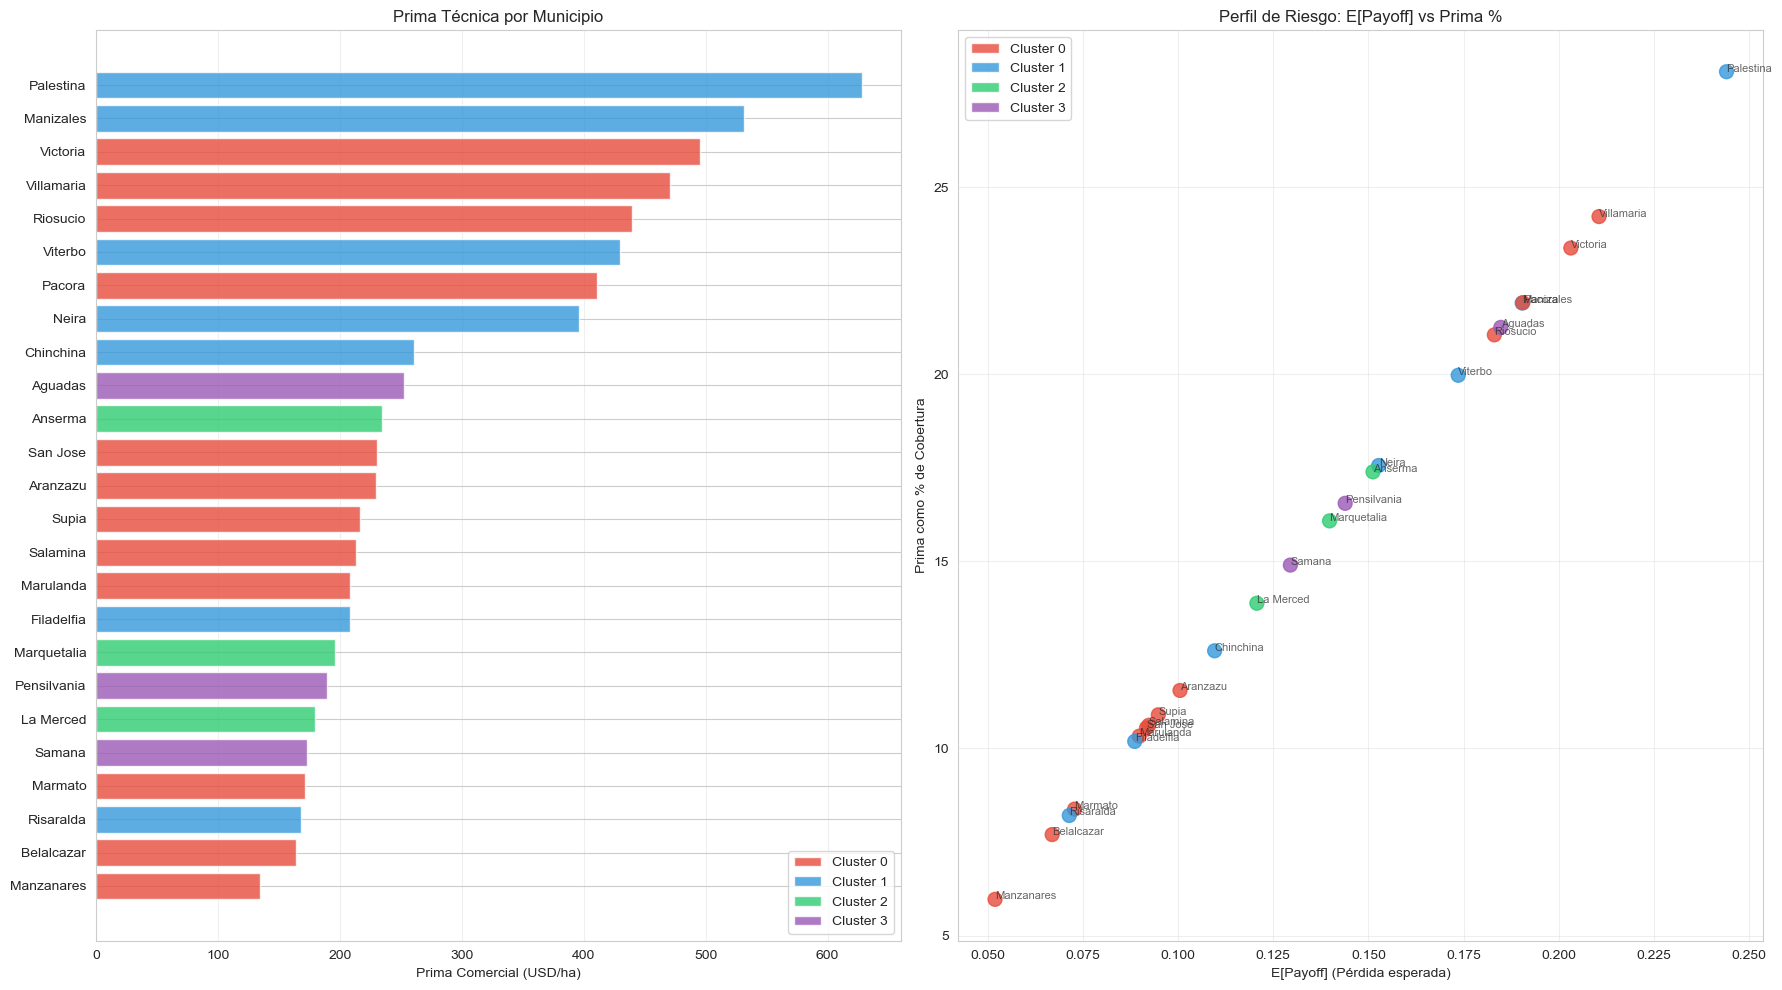

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

primas_sorted = primas_df.sort_values('Prima_comercial_USD')
colors_clusters = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#9b59b6'}
colors_bars = [colors_clusters[c] for c in primas_sorted['Cluster']]

axes[0].barh(primas_sorted['Municipio'], primas_sorted['Prima_comercial_USD'], color=colors_bars, alpha=0.8)
axes[0].set_xlabel('Prima Comercial (USD/ha)')
axes[0].set_title('Prima Técnica por Municipio')
axes[0].grid(alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.8, label=f'Cluster {c}') 
                   for c, color in colors_clusters.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

axes[1].scatter(primas_df['E_Payoff'], primas_df['Prima_pct_cobertura'], 
                s=100, c=[colors_clusters[c] for c in primas_df['Cluster']], alpha=0.8)
for _, row in primas_df.iterrows():
    axes[1].annotate(row['Municipio'], (row['E_Payoff'], row['Prima_pct_cobertura']),
                     fontsize=8, alpha=0.7)
axes[1].set_xlabel('E[Payoff] (Pérdida esperada)')
axes[1].set_ylabel('Prima como % de Cobertura')
axes[1].set_title('Perfil de Riesgo: E[Payoff] vs Prima %')
axes[1].grid(alpha=0.3)
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()